# Week 2 - Preprocessing

---

## 1. Lesson: None
---

## 2. Weekly graph question
The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story. Write down a possible Who, What, and How for your data, using the ideas in the book:


---

**Who**:
The target audience for this project is NBA coaching staff who want to identify the performance styles that separate successful teams from unsuccessful teams.

**What**:
Performance Metrics Associated with NBA Team Success.

**How**:
The Team Traditional dataset supports the project goal by showing the basic box-score statistics that describe what successful teams produce during games, such as scoring, rebounding, assists, turnovers, and shooting.

The Team Advanced dataset supports the project goal by showing efficiency and impact metrics that help explain why some teams perform better than others, including offensive rating, defensive rating, net rating, pace, and shooting efficiency.

The Player Traditional dataset supports the project goal by showing individual box-score production patterns, such as points, rebounds, assists, steals, blocks, and turnovers, which may help describe the types of player contributions found on successful teams.

The Player Advanced dataset supports the project goal by showing player efficiency, role, usage, and impact metrics that may help explain how individual contributions support overall team success.

---

## 3. Homework - work with your own data: Sports Analytics (NBA Game Outcome & Sports Betting Market Analysis)



  - Summarize the datasets using info() and describe(): 3.0

  - Are there any duplicate rows? 3.1.2

  - Are there any duplicate values in a given column (when this would be inappropriate?) 3.1.2

  - What are the mean, median, and mode of each column? 3.2

  - Are there any missing or null values? 3.1.2
      - Do you want to fill in the missing value with a mean value? A value of your choice? Remove that row? no missing values found.

  - Identify any other inconsistent data: 3.1.2

  - Encode any categorical variables (e.g. with one-hot encoding.) 3.4

---

Conclusions:

  - Are the data usable? If not, find some new data! Yes, those are the new datasets i found to replace provided datasets.

  - Do you need to modify or correct the data in some way? 3.1.1

    Is there any class imbalance? (Categories that have many more items than other categories).


In [1]:
!pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
# @title **imports**
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns


### **3.0: Read CSV file and stored data into panda dataframes. Display the summary of data.**


Player Traditional Dataset

- Variables: PTS, REB, AST, STL, BLK, TOV, FG_PCT, FG3_PCT, FT_PCT, PLUS_MINUS, MIN


| Column              | Why it matters                                                                       |
| ------------------- | ------------------------------------------------------------------------------------ |
| `PLAYER_NAME`       | Identifies each player.                                                              |
| `TEAM_ABBREVIATION` | Needed to group players by team.                                                     |
| `GP`                | Helps filter out players with very few games.                                        |
| `MIN`               | Shows playing time; important because high-impact players usually play more minutes. |
| `PTS`               | Measures scoring production.                                                         |
| `REB`               | Measures rebounding contribution.                                                    |
| `AST`               | Measures playmaking contribution.                                                    |
| `STL`               | Measures defensive activity.                                                         |
| `BLK`               | Measures shot-blocking and rim protection.                                           |
| `TOV`               | Negative offensive metric; turnovers hurt team performance.                          |
| `FG_PCT`            | Basic shooting efficiency.                                                           |
| `FG3_PCT`           | Three-point shooting efficiency.                                                     |
| `FT_PCT`            | Useful secondary shooting-efficiency variable.                                       |
| `PLUS_MINUS`        | Estimates score impact while the player is on the court.                             |


In [3]:
'''dataset player tradition'''
# player_traditional = leaguedashplayerstats.LeagueDashPlayerStats(
#     season="2023-24",
#     season_type_all_star="Regular Season",
#     per_mode_detailed="PerGame",
#     measure_type_detailed_defense="Base"
# ).get_data_frames()[0]

# player_traditional.to_csv("data/nba_player_traditional_2023_24_regular.csv", index=False)
df_player_traditional = pd.read_csv("https://raw.githubusercontent.com/SuhuanPan-BU/nba-dataset/refs/heads/main/Original_Datasets/nba_player_traditional_2023_24.csv")

display(df_player_traditional.info())
display(df_player_traditional.describe())

<class 'pandas.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 67 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PLAYER_ID              572 non-null    int64  
 1   PLAYER_NAME            572 non-null    str    
 2   NICKNAME               572 non-null    str    
 3   TEAM_ID                572 non-null    int64  
 4   TEAM_ABBREVIATION      572 non-null    str    
 5   AGE                    572 non-null    float64
 6   GP                     572 non-null    int64  
 7   W                      572 non-null    int64  
 8   L                      572 non-null    int64  
 9   W_PCT                  572 non-null    float64
 10  MIN                    572 non-null    float64
 11  FGM                    572 non-null    float64
 12  FGA                    572 non-null    float64
 13  FG_PCT                 572 non-null    float64
 14  FG3M                   572 non-null    float64
 15  FG3A             

None

,PLAYER_ID,TEAM_ID,AGE,GP,W,L,W_PCT,MIN,FGM,FGA,...,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT
count,5.720000e+02,5.720000e+02,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.00000,572.000000,...,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000
mean,1.378544e+06,1.610613e+09,26.173077,46.155594,23.166084,22.989510,0.484956,18.647378,3.12028,6.683392,...,283.979021,285.660839,285.538462,286.253497,286.344406,286.472028,193.505245,36.339161,286.421329,1.148601
std,5.463796e+05,8.748871e+00,4.257447,25.536868,16.295499,14.181581,0.202371,9.910638,2.45884,4.991255,...,162.055610,164.445756,164.103755,164.955698,165.246222,165.223844,81.695764,6.441737,165.172168,0.388920
min,2.544000e+03,1.610613e+09,19.000000,1.000000,0.000000,0.000000,0.000000,0.400000,0.00000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.627848e+06,1.610613e+09,23.000000,22.000000,8.000000,12.000000,0.339750,10.800000,1.30000,3.000000,...,143.750000,143.750000,143.750000,143.750000,143.750000,143.750000,135.000000,38.000000,143.750000,1.000000
50%,1.629724e+06,1.610613e+09,25.000000,51.000000,22.000000,24.000000,0.530000,17.350000,2.40000,5.100000,...,286.000000,286.500000,286.000000,286.500000,286.500000,286.500000,257.000000,38.000000,286.500000,1.000000
75%,1.630702e+06,1.610613e+09,28.000000,69.000000,37.000000,32.000000,0.618000,27.000000,4.50000,9.100000,...,428.000000,429.250000,429.250000,428.500000,429.250000,429.250000,257.000000,38.000000,429.250000,1.000000
max,1.642013e+06,1.610613e+09,39.000000,84.000000,64.000000,65.000000,1.000000,37.800000,11.50000,23.600000,...,525.000000,556.000000,547.000000,563.000000,572.000000,568.000000,257.000000,38.000000,568.000000,3.000000


Player Advanced Dataset:

  | Column              | Why it matters                                                                    |
| ------------------- | --------------------------------------------------------------------------------- |
| `PLAYER_NAME`       | Needed for merging with player traditional stats.                                 |
| `TEAM_ABBREVIATION` | Needed to group players by team.                                                  |
| `GP`                | Helps remove small-sample players.                                                |
| `MIN`               | Helps identify important rotation players.                                        |
| `OFF_RATING`        | Points scored per 100 possessions while the player is on court.                   |
| `DEF_RATING`        | Points allowed per 100 possessions while the player is on court; lower is better. |
| `NET_RATING`        | Difference between offensive and defensive rating; strong impact metric.          |
| `AST_PCT`           | Measures the player’s playmaking role.                                            |
| `REB_PCT`           | Measures rebounding impact adjusted for opportunities.                            |
| `USG_PCT`           | Shows how much offense runs through the player.                                   |
| `TS_PCT`            | Strong overall scoring-efficiency metric.                                         |
| `EFG_PCT`           | Shooting efficiency adjusted for three-pointers.                                  |
| `PIE`               | Overall box-score impact estimate.                                                |
| `PACE`              | Optional style variable showing speed of play.                                    |


In [4]:

# player_advanced = leaguedashplayerstats.LeagueDashPlayerStats(
#     season="2023-24",
#     season_type_all_star="Regular Season",
#     per_mode_detailed="PerGame",
#     measure_type_detailed_defense="Advanced"
# ).get_data_frames()[0]

# player_advanced.to_csv("nba_player_advanced_2023_24_regular.csv", index=False)
df_player_advanced = pd.read_csv("https://raw.githubusercontent.com/SuhuanPan-BU/nba-dataset/refs/heads/main/Original_Datasets/nba_player_advanced_2023_24.csv")
display(df_player_advanced.info())
display(df_player_advanced.describe())

<class 'pandas.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 79 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   PLAYER_ID                572 non-null    int64  
 1   PLAYER_NAME              572 non-null    str    
 2   NICKNAME                 572 non-null    str    
 3   TEAM_ID                  572 non-null    int64  
 4   TEAM_ABBREVIATION        572 non-null    str    
 5   AGE                      572 non-null    float64
 6   GP                       572 non-null    int64  
 7   W                        572 non-null    int64  
 8   L                        572 non-null    int64  
 9   W_PCT                    572 non-null    float64
 10  MIN                      572 non-null    float64
 11  E_OFF_RATING             572 non-null    float64
 12  OFF_RATING               572 non-null    float64
 13  sp_work_OFF_RATING       572 non-null    float64
 14  E_DEF_RATING             572 non-null

None

,PLAYER_ID,TEAM_ID,AGE,GP,W,L,W_PCT,MIN,E_OFF_RATING,OFF_RATING,...,E_PACE_RANK,PACE_RANK,sp_work_PACE_RANK,PIE_RANK,FGM_RANK,FGA_RANK,FGM_PG_RANK,FGA_PG_RANK,FG_PCT_RANK,TEAM_COUNT
count,5.720000e+02,5.720000e+02,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,...,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000
mean,1.378544e+06,1.610613e+09,26.173077,46.155594,23.166084,22.989510,0.484956,18.647378,109.366259,109.155070,...,286.500000,286.500000,286.500000,286.487762,285.298951,286.006993,286.020979,286.213287,286.076923,1.148601
std,5.463796e+05,8.748871e+00,4.257447,25.536868,16.295499,14.181581,0.202371,9.910638,11.589434,12.245335,...,165.266452,165.266452,165.266452,165.246284,164.123495,164.851735,164.720364,164.918151,165.081175,0.388920
min,2.544000e+03,1.610613e+09,19.000000,1.000000,0.000000,0.000000,0.000000,0.400000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.627848e+06,1.610613e+09,23.000000,22.000000,8.000000,12.000000,0.339750,10.800000,106.300000,105.800000,...,143.750000,143.750000,143.750000,143.750000,143.750000,143.750000,143.750000,143.750000,139.000000,1.000000
50%,1.629724e+06,1.610613e+09,25.000000,51.000000,22.000000,24.000000,0.530000,17.350000,110.700000,110.900000,...,286.500000,286.500000,286.500000,286.500000,286.500000,286.000000,286.500000,286.500000,286.500000,1.000000
75%,1.630702e+06,1.610613e+09,28.000000,69.000000,37.000000,32.000000,0.618000,27.000000,114.925000,115.225000,...,429.250000,429.250000,429.250000,429.250000,427.000000,429.250000,429.000000,429.250000,429.250000,1.000000
max,1.642013e+06,1.610613e+09,39.000000,84.000000,64.000000,65.000000,1.000000,37.800000,174.100000,183.300000,...,572.000000,572.000000,572.000000,572.000000,561.000000,569.000000,561.000000,569.000000,561.000000,3.000000


Team Traditional Dataset

| Column              | Why it matters                                       |
| ------------------- | ---------------------------------------------------- |
| `TEAM_NAME`         | Identifies each team.                                |
| `TEAM_ABBREVIATION` | Useful for merging with player data.                 |
| `GP`                | Confirms the same season sample.                     |
| `W`                 | Team wins.                                           |
| `L`                 | Team losses.                                         |
| `W_PCT`             | Main team-success outcome variable.                  |
| `PTS`               | Team scoring output.                                 |
| `REB`               | Team rebounding production.                          |
| `AST`               | Team ball movement and playmaking.                   |
| `TOV`               | Team mistakes and lost possessions.                  |
| `FG_PCT`            | Team shooting efficiency.                            |
| `FG3_PCT`           | Team three-point shooting efficiency.                |
| `PLUS_MINUS`        | Team scoring margin; strong team-performance metric. |



In [5]:

# team_traditional = leaguedashteamstats.LeagueDashTeamStats(
#     season="2023-24",
#     season_type_all_star="Regular Season",
#     per_mode_detailed="PerGame",
#     measure_type_detailed_defense="Base"
# ).get_data_frames()[0]

# team_traditional.to_csv("nba_team_traditional_2023_24_regular.csv", index=False)
df_team_traditional = pd.read_csv("https://raw.githubusercontent.com/SuhuanPan-BU/nba-dataset/refs/heads/main/Original_Datasets/nba_team_traditional_2023_24.csv")
display(df_team_traditional.info())
display(df_team_traditional.describe())


<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 54 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TEAM_ID          30 non-null     int64  
 1   TEAM_NAME        30 non-null     str    
 2   GP               30 non-null     int64  
 3   W                30 non-null     int64  
 4   L                30 non-null     int64  
 5   W_PCT            30 non-null     float64
 6   MIN              30 non-null     float64
 7   FGM              30 non-null     float64
 8   FGA              30 non-null     float64
 9   FG_PCT           30 non-null     float64
 10  FG3M             30 non-null     float64
 11  FG3A             30 non-null     float64
 12  FG3_PCT          30 non-null     float64
 13  FTM              30 non-null     float64
 14  FTA              30 non-null     float64
 15  FT_PCT           30 non-null     float64
 16  OREB             30 non-null     float64
 17  DREB             30 non-null 

None

,TEAM_ID,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,FG3M,...,REB_RANK,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK
count,3.000000e+01,30.0,30.000000,30.000000,30.00000,30.00000,30.000000,30.000000,30.000000,30.000000,...,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,1.610613e+09,82.0,41.000000,41.000000,0.50000,48.27000,42.176667,88.903333,0.474300,12.840000,...,15.466667,15.500000,15.400000,15.433333,15.400000,15.466667,15.500000,15.466667,15.500000,15.466667
std,8.803408e+00,0.0,13.411266,13.411266,0.16355,0.14657,1.717995,2.073558,0.016912,1.217572,...,8.850222,8.803408,8.814565,8.842231,8.892461,8.752274,8.803408,8.760150,8.803408,8.826814
min,1.610613e+09,82.0,14.000000,18.000000,0.17100,48.10000,38.400000,84.900000,0.435000,11.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.610613e+09,82.0,31.250000,33.000000,0.38100,48.12500,41.300000,87.425000,0.464250,12.100000,...,8.250000,8.250000,8.250000,8.250000,8.250000,8.250000,8.250000,8.250000,8.250000,8.250000
50%,1.610613e+09,82.0,46.500000,35.500000,0.56700,48.30000,42.150000,89.200000,0.473500,12.600000,...,15.500000,15.500000,15.500000,15.500000,15.000000,15.500000,15.500000,15.500000,15.500000,15.500000
75%,1.610613e+09,82.0,49.000000,50.750000,0.59800,48.40000,43.100000,90.125000,0.486750,13.300000,...,22.750000,22.750000,22.750000,22.750000,22.750000,22.750000,22.750000,22.750000,22.750000,22.750000
max,1.610613e+09,82.0,64.000000,68.000000,0.78000,48.70000,47.000000,92.700000,0.507000,16.500000,...,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000


Team Advanced Dataset

| Column       | Why it matters                                        |
| ------------ | ----------------------------------------------------- |
| `TEAM_NAME`  | Identifies each team.                                 |
| `GP`         | Confirms the same season sample.                      |
| `W`          | Team wins.                                            |
| `L`          | Team losses.                                          |
| `W_PCT`      | Main team-success outcome variable.                   |
| `OFF_RATING` | Team offensive efficiency.                            |
| `DEF_RATING` | Team defensive efficiency; lower is better.           |
| `NET_RATING` | Best overall team-quality metric.                     |
| `AST_PCT`    | Measures team ball movement.                          |
| `AST_TO`     | Measures assist-to-turnover efficiency.               |
| `REB_PCT`    | Measures team rebounding control.                     |
| `TS_PCT`     | Team overall scoring efficiency.                      |
| `EFG_PCT`    | Team shooting efficiency adjusted for three-pointers. |
| `PACE`       | Team playing speed/style.                             |
| `PIE`        | Overall team impact estimate.                         |


In [6]:

# team_advanced = leaguedashteamstats.LeagueDashTeamStats(
#     season="2023-24",
#     season_type_all_star="Regular Season",
#     per_mode_detailed="PerGame",
#     measure_type_detailed_defense="Advanced"
# ).get_data_frames()[0]

# team_advanced.to_csv("nba_team_advanced_2023_24_regular.csv", index=False)
df_team_advanced = pd.read_csv("https://raw.githubusercontent.com/SuhuanPan-BU/nba-dataset/refs/heads/main/Original_Datasets/nba_team_advanced_2023_24.csv")

display(df_team_advanced.info())
display(df_team_advanced.describe())

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 46 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TEAM_ID          30 non-null     int64  
 1   TEAM_NAME        30 non-null     str    
 2   GP               30 non-null     int64  
 3   W                30 non-null     int64  
 4   L                30 non-null     int64  
 5   W_PCT            30 non-null     float64
 6   MIN              30 non-null     float64
 7   E_OFF_RATING     30 non-null     float64
 8   OFF_RATING       30 non-null     float64
 9   E_DEF_RATING     30 non-null     float64
 10  DEF_RATING       30 non-null     float64
 11  E_NET_RATING     30 non-null     float64
 12  NET_RATING       30 non-null     float64
 13  AST_PCT          30 non-null     float64
 14  AST_TO           30 non-null     float64
 15  AST_RATIO        30 non-null     float64
 16  OREB_PCT         30 non-null     float64
 17  DREB_PCT         30 non-null 

None

,TEAM_ID,GP,W,L,W_PCT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,...,AST_TO_RANK,AST_RATIO_RANK,OREB_PCT_RANK,DREB_PCT_RANK,REB_PCT_RANK,TM_TOV_PCT_RANK,EFG_PCT_RANK,TS_PCT_RANK,PACE_RANK,PIE_RANK
count,3.000000e+01,30.0,30.000000,30.000000,30.00000,30.000000,30.000000,30.000000,30.000000,30.000000,...,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,1.610613e+09,82.0,41.000000,41.000000,0.50000,3958.333333,112.516667,114.546667,112.493333,114.516667,...,15.500000,15.500000,15.500000,15.500000,15.500000,15.500000,15.500000,15.500000,15.500000,15.500000
std,8.803408e+00,0.0,13.411266,13.411266,0.16355,12.712561,3.804451,3.783789,2.849674,2.885288,...,8.803408,8.803408,8.803408,8.803408,8.803408,8.803408,8.803408,8.803408,8.803408,8.803408
min,1.610613e+09,82.0,14.000000,18.000000,0.17100,3941.000000,104.200000,106.800000,106.200000,108.400000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.610613e+09,82.0,31.250000,33.000000,0.38100,3947.250000,110.450000,112.525000,110.550000,112.325000,...,8.250000,8.250000,8.250000,8.250000,8.250000,8.250000,8.250000,8.250000,8.250000,8.250000
50%,1.610613e+09,82.0,46.500000,35.500000,0.56700,3961.000000,113.350000,115.050000,112.500000,114.550000,...,15.500000,15.500000,15.500000,15.500000,15.500000,15.500000,15.500000,15.500000,15.500000,15.500000
75%,1.610613e+09,82.0,49.000000,50.750000,0.59800,3966.000000,114.975000,116.975000,114.325000,116.375000,...,22.750000,22.750000,22.750000,22.750000,22.750000,22.750000,22.750000,22.750000,22.750000,22.750000
max,1.610613e+09,82.0,64.000000,68.000000,0.78000,3996.000000,120.200000,122.200000,117.700000,119.600000,...,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000


## 3.1 **Preprocessing Phase**

---
Step 1 focused on removing duplicate, identical, and unrelated columns. Columns that did not support the research question were removed, including identifier fields, ranking fields, fantasy-score fields, internal metadata fields, and low-priority descriptive fields. The retained columns focus on player production, efficiency, role, and team success metrics.

Step 2 checked all columns for missing values. Standard missing values were checked across all columns, and text columns were also checked for empty strings. This helped confirm whether any columns required cleaning before analysis.

Step 3 checked for duplicate records and duplicate key values. In the team datasets, TEAM_ID should be unique because each row represents one team. In the player datasets, PLAYER_ID should be unique if each row represents one player. TEAM_ID is not expected to be unique in the player datasets because multiple players can belong to the same team. This step helped confirm that the datasets did not contain duplicated records before moving into the analysis phase.

All datasets passed the checks from Steps 1 through 3.

In Step 4, the percentage columns were checked to confirm that their values were within the expected range of 0 to 1. The initial check flagged TM_TOV_PCT and E_TOV_PCT in the Player Advanced dataset because many values were greater than 1.

After reviewing the actual ranges, both columns had values from 0.0 to 57.1. This indicates that these columns were stored as percentage-point values rather than decimal proportions. For example, a value of 57.1 represents 57.1%, not 57.1 as a decimal value. Therefore, TM_TOV_PCT and E_TOV_PCT were not treated as data errors. Instead, they were converted to decimal proportions by dividing by 100, After conversion, the values were rounded to three decimal places so the values would be consistent with the other percentage columns. This conversion was necessary before moving into the next phase of data analysis.



### 3.1.1 check exact duplicate columns
### 3.1.2 drop unneeded columns

---



In [7]:
'''3.1.1 check exact duplicate columns'''
def find_duplicate_columns(df):
    duplicate_pairs = []

    cols = df.columns.tolist()

    for i, col1 in enumerate(cols):
        for col2 in cols[i + 1:]:

            same_values = df[col1].equals(df[col2])
            differences = (df[col1] != df[col2]).sum()

            if same_values:
                print(f"{col1} vs {col2}")
                print(f"Same values: {same_values}")
                print(f"Number of different rows: {differences}")
                print()
                duplicate_pairs.append((col1, col2))

    return duplicate_pairs

In [8]:
'''3.1.1'''
def drop_unneeded_columns(df, drop_cols, drop_rank_cols=True):
    '''Drop selected columns from a DataFrame.
    Optionally drops all columns that contain 'RANK'.'''

    df_clean = df.copy()

    # Start with manually listed columns
    columns_to_drop = [col for col in drop_cols if col in df_clean.columns]

    # Add columns containing 'RANK'
    if drop_rank_cols:
        rank_cols = [col for col in df_clean.columns if "RANK" in col]
        columns_to_drop = columns_to_drop + rank_cols

    # Remove duplicates from drop list
    columns_to_drop = list(set(columns_to_drop))


    print(f"Dropping {len(columns_to_drop)} columns...")
    df_clean = df_clean.drop(columns=columns_to_drop)
    print(f"Remaining {len(df_clean.columns)} columns.")

    return df_clean

In [9]:
''' Player Traditional'''

find_duplicate_columns(df_player_traditional)





[]

In [10]:
player_traditional_drop_cols = [
    "NICKNAME",
    "AGE",
    "BLKA",
    "PF",
    "PFD",
    "NBA_FANTASY_PTS",
    "WNBA_FANTASY_PTS",
    "DD2",
    "TD3",
    "CFID",
    "CFPARAMS"
]

df_player_traditional = drop_unneeded_columns(
    df_player_traditional,
    player_traditional_drop_cols
)


Dropping 39 columns...
Remaining 28 columns.


In [11]:
'''player advanced'''
find_duplicate_columns(df_player_advanced)

OFF_RATING vs sp_work_OFF_RATING
Same values: True
Number of different rows: 0

DEF_RATING vs sp_work_DEF_RATING
Same values: True
Number of different rows: 0

NET_RATING vs sp_work_NET_RATING
Same values: True
Number of different rows: 0

PACE vs sp_work_PACE
Same values: True
Number of different rows: 0

OFF_RATING_RANK vs sp_work_OFF_RATING_RANK
Same values: True
Number of different rows: 0

DEF_RATING_RANK vs sp_work_DEF_RATING_RANK
Same values: True
Number of different rows: 0

NET_RATING_RANK vs sp_work_NET_RATING_RANK
Same values: True
Number of different rows: 0

PACE_RANK vs sp_work_PACE_RANK
Same values: True
Number of different rows: 0



[('OFF_RATING', 'sp_work_OFF_RATING'),
 ('DEF_RATING', 'sp_work_DEF_RATING'),
 ('NET_RATING', 'sp_work_NET_RATING'),
 ('PACE', 'sp_work_PACE'),
 ('OFF_RATING_RANK', 'sp_work_OFF_RATING_RANK'),
 ('DEF_RATING_RANK', 'sp_work_DEF_RATING_RANK'),
 ('NET_RATING_RANK', 'sp_work_NET_RATING_RANK'),
 ('PACE_RANK', 'sp_work_PACE_RANK')]

In [12]:
'''player advanced'''

## dropping unneeded and duplicate columns
player_advanced_drop_cols = [
    "NICKNAME",
    "AGE",
    "POSS",
    "CFID",
    "CFPARAMS",
    #  duplicates
    "sp_work_OFF_RATING",
    "sp_work_DEF_RATING",
    "sp_work_NET_RATING",
    "sp_work_PACE",
    "sp_work_OFF_RATING_RANK",
    "sp_work_DEF_RATING_RANK",
    "sp_work_NET_RATING_RANK",
    "sp_work_PACE_RANK"
]

df_player_advanced = drop_unneeded_columns(
    df_player_advanced,
    player_advanced_drop_cols
)


Dropping 42 columns...
Remaining 37 columns.


In [13]:
find_duplicate_columns(df_team_traditional)

W_RANK vs L_RANK
Same values: True
Number of different rows: 0

W_RANK vs W_PCT_RANK
Same values: True
Number of different rows: 0

L_RANK vs W_PCT_RANK
Same values: True
Number of different rows: 0



[('W_RANK', 'L_RANK'), ('W_RANK', 'W_PCT_RANK'), ('L_RANK', 'W_PCT_RANK')]

In [14]:
'''team traditional'''
team_traditional_drop_cols = [
    "GROUP_SET",
    "NBA_FANTASY_PTS",
    "WNBA_FANTASY_PTS",
    "CFID",
    "CFPARAMS",
    # duplicates
    "W_RANK",
    "L_RANK"

]
df_team_traditional = drop_unneeded_columns(
    df_team_traditional,
    team_traditional_drop_cols
)




Dropping 26 columns...
Remaining 28 columns.


In [15]:
find_duplicate_columns(df_team_advanced)

W_RANK vs L_RANK
Same values: True
Number of different rows: 0

W_RANK vs W_PCT_RANK
Same values: True
Number of different rows: 0

L_RANK vs W_PCT_RANK
Same values: True
Number of different rows: 0



[('W_RANK', 'L_RANK'), ('W_RANK', 'W_PCT_RANK'), ('L_RANK', 'W_PCT_RANK')]

In [16]:
team_advanced_drop_cols = [
    "GROUP_SET",
    "POSS",
    "CFID",
    "CFPARAMS"
    # duplicates
    "W_RANK",
    "L_RANK"

]

df_team_advanced = drop_unneeded_columns(
    df_team_advanced,
    team_advanced_drop_cols
)

# df_team_advanced_clean.info()

Dropping 20 columns...
Remaining 26 columns.


### 3.1.2 Check Data Inconsistancy



In [17]:
'''3.1.2'''
def check_data_inconsistancy(df, dataset_name, unique_columns):
    ''' Check common data quality issues in a DataFrame:
    1. duplicate column names
    2. missing values and null value
    3. empty strings in object columns
    4a. duplicate rows for the entire dataframe
    4b. Duplicate records based on selected key columns
    5. Inconsistancy in percentage columns (should be 0 to 1)
    display general infomation of column types, return None'''

    print(f"\n\n--------- {dataset_name} ----------")
    print(f"Shape: {df.shape}")


    # Duplicate column names
    duplicate_columns = df.columns[df.columns.duplicated()].tolist()
    print(f"Step 1. Duplicate columns: {duplicate_columns}")

    # Standard missing values: NaN, None, NaT
    missing_summary = df.isna().sum()
    missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)


    print(f"Step 2a. Columns with standard missing values: {len(missing_summary)}")
    if len(missing_summary) > 0:
        print(missing_summary)

    # Empty strings in object columns
    object_cols = df.select_dtypes(include="object").columns

    empty_string_summary = {}

    for col in object_cols:
        empty_count = df[col].astype(str).str.strip().eq("").sum()
        if empty_count > 0:
            empty_string_summary[col] = empty_count

    print(f"Step 2b. Object columns with empty strings: {len(empty_string_summary)}")
    if len(empty_string_summary) > 0:
        print(empty_string_summary)


    # Duplicate rows
    duplicate_rows = df.duplicated().sum()
    print(f"Step 3a. Duplicate rows: {duplicate_rows}")

    # Duplicate records based on selected key columns
    missing_cols = [col for col in unique_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing selected key columns: {missing_cols}")

    duplicate_count = df.duplicated(subset=unique_columns).sum()

    print(f"Step 3b. Number of duplicate records based on {unique_columns}: {duplicate_count}")

    if duplicate_count > 0:
        display(df[df.duplicated(subset=unique_columns, keep=False)].sort_values(unique_columns))


    # percentage_range should between 0 and 1
    print(f"Step 4. Inconsistancy in percentage columns:")
    pct_cols = [
        col for col in df.columns
        if "PCT" in col or col.endswith("_PCT")
    ]
    for col in pct_cols:
        invalid = df[(df[col].notna()) & ((df[col] < 0) | (df[col] > 1))]

        if len(invalid) > 0:
            print(f"{col}: {len(invalid)} invalid values")

    # Data types
    print("Data types:")
    print(df.dtypes.value_counts())

    return None

In [18]:
# inappropriate if each team id isn't unique
check_data_inconsistancy(df_team_traditional,
dataset_name="Team Traditional",
                         unique_columns=["TEAM_ID"])





--------- Team Traditional ----------
Shape: (30, 28)
Step 1. Duplicate columns: []
Step 2a. Columns with standard missing values: 0
Step 2b. Object columns with empty strings: 0
Step 3a. Duplicate rows: 0
Step 3b. Number of duplicate records based on ['TEAM_ID']: 0
Step 4. Inconsistancy in percentage columns:
Data types:
float64    23
int64       4
str         1
Name: count, dtype: int64


/tmp/ipykernel_8344/1938634889.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include="object").columns


In [19]:
check_data_inconsistancy(df_team_advanced,
                         dataset_name="Team Advanced",
                         unique_columns=["TEAM_ID"])



--------- Team Advanced ----------
Shape: (30, 26)
Step 1. Duplicate columns: []
Step 2a. Columns with standard missing values: 0
Step 2b. Object columns with empty strings: 0
Step 3a. Duplicate rows: 0
Step 3b. Number of duplicate records based on ['TEAM_ID']: 0
Step 4. Inconsistancy in percentage columns:
Data types:
float64    21
int64       4
str         1
Name: count, dtype: int64


/tmp/ipykernel_8344/1938634889.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include="object").columns


In [20]:

# inappropriate if one player plays for different team
check_data_inconsistancy(df_player_traditional,
                         dataset_name="Player Traditional",
                         unique_columns=["PLAYER_ID", "TEAM_ID"])








--------- Player Traditional ----------
Shape: (572, 28)
Step 1. Duplicate columns: []
Step 2a. Columns with standard missing values: 0
Step 2b. Object columns with empty strings: 0
Step 3a. Duplicate rows: 0
Step 3b. Number of duplicate records based on ['PLAYER_ID', 'TEAM_ID']: 0
Step 4. Inconsistancy in percentage columns:
Data types:
float64    20
int64       6
str         2
Name: count, dtype: int64


/tmp/ipykernel_8344/1938634889.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include="object").columns


In [21]:
check_data_inconsistancy(df_player_advanced,
                         dataset_name="Player Advanced",
                         unique_columns=["PLAYER_ID", "TEAM_ID"])



--------- Player Advanced ----------
Shape: (572, 37)
Step 1. Duplicate columns: []
Step 2a. Columns with standard missing values: 0
Step 2b. Object columns with empty strings: 0
Step 3a. Duplicate rows: 0
Step 3b. Number of duplicate records based on ['PLAYER_ID', 'TEAM_ID']: 0
Step 4. Inconsistancy in percentage columns:
TM_TOV_PCT: 549 invalid values
E_TOV_PCT: 549 invalid values
Data types:
float64    27
int64       8
str         2
Name: count, dtype: int64


/tmp/ipykernel_8344/1938634889.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include="object").columns


In [22]:
'''3.1.3 handle the above issue: 
Convert turnover percentage columns from percentage-point values to decimal proportions'''
cols_to_convert = ["TM_TOV_PCT", "E_TOV_PCT"]

for col in cols_to_convert:
    if df_player_advanced[col].max() > 1:
        df_player_advanced[col] = (df_player_advanced[col] / 100).round(3)

## 3.2 Numerical Columns Summery

`def numerical_cols_statistic_summary(df, dataset_name)`

In [23]:
'''3.2'''
def numerical_cols_statistic_summary(df, dataset_name):
  '''display mean, median and mode for numerical columns,
    excluding columns with ID in the column name,
    round with 2 digits and avoid scientific notation'''

  print(f"\n\n--------- {dataset_name} ----------")

  # select numeric columns
  numeric_df = df.select_dtypes(include="number")

  # remove columns with ID in the column name, such as PLAYER_ID, TEAM_ID, CFID
  numeric_df = numeric_df.loc[:, ~numeric_df.columns.str.contains("ID", case=False)]

  summary_stats = pd.DataFrame({
      "mean": numeric_df.mean(),
      "median": numeric_df.median(),
      "mode": numeric_df.mode().iloc[0]
  }).round(2)

  # avoid scientific notation when displaying
  with pd.option_context("display.float_format", "{:.2f}".format):
      display(summary_stats)

  return None

In [24]:
'''display mean, median and mode for all numerical column'''

numerical_cols_statistic_summary(df_team_traditional, "Team Traditional")

numerical_cols_statistic_summary(df_team_advanced, "Team Advanced")

numerical_cols_statistic_summary(df_player_traditional, "Player Traditional")

numerical_cols_statistic_summary(df_player_advanced, "Player Advanced")





--------- Team Traditional ----------


,mean,median,mode
GP,82.00,82.00,82.00
W,41.00,46.50,47.00
L,41.00,35.50,35.00
W_PCT,0.50,0.57,0.57
MIN,48.27,48.30,48.10
FGM,42.18,42.15,41.30
FGA,88.90,89.20,89.70
FG_PCT,0.47,0.47,0.46
FG3M,12.84,12.60,11.50
FG3A,35.11,34.75,32.60




--------- Team Advanced ----------


,mean,median,mode
GP,82.00,82.00,82.00
W,41.00,46.50,47.00
L,41.00,35.50,35.00
W_PCT,0.50,0.57,0.57
MIN,3958.33,3961.00,3961.00
E_OFF_RATING,112.52,113.35,113.80
OFF_RATING,114.55,115.05,116.20
E_DEF_RATING,112.49,112.50,106.20
DEF_RATING,114.52,114.55,113.70
E_NET_RATING,0.03,2.10,0.90




--------- Player Traditional ----------


,mean,median,mode
GP,46.16,51.00,68.00
W,23.17,22.00,2.00
L,22.99,24.00,24.00
W_PCT,0.48,0.53,0.50
MIN,18.65,17.35,7.40
FGM,3.12,2.40,1.50
FGA,6.68,5.10,1.00
FG_PCT,0.45,0.45,0.00
FG3M,0.94,0.70,0.00
FG3A,2.65,2.10,0.00




--------- Player Advanced ----------


,mean,median,mode
GP,46.16,51.00,68.00
W,23.17,22.00,2.00
L,22.99,24.00,24.00
W_PCT,0.48,0.53,0.50
MIN,18.65,17.35,7.40
E_OFF_RATING,109.37,110.70,110.60
OFF_RATING,109.16,110.90,109.90
E_DEF_RATING,112.12,112.25,113.90
DEF_RATING,111.67,112.55,111.10
E_NET_RATING,-2.75,-1.25,0.00


## 3.3 Check Class Imbalance


Test "TEAM_ABBREVIATION" colun on both player datasets. Result: Imbalance ratio = 1.41 for both player datasets, means the largest team class has about 1.41 times as many players rows as the smallest team class. For a dataset that contains 30 unique teams, this is a minor class imbalance problem. No balancing correction is needed for both player traditional and player advanced datasets.


Test "TEAM_NAME" column on both team datasets, Result: the class distribution is perfectlu balanced, number of classes equal to number of unique teams means each team appeared equally in the team traditional and team advanced datasets.

---

`def cat_cols_class_balance_summery(df, column, dataset_name)`

In [25]:
'''3.3.'''
def cat_cols_class_balance_summery(df, column, dataset_name):
  '''  Check class balance for a categorical column.
  Displays count, percentage, and imbalance ratio.'''

  print(f"\n\n--------- {dataset_name} ----------")

  if column not in df.columns:
    raise ValueError(f"Column '{column}' not found in DataFrame.")

  counts = df[column].value_counts(dropna=False)
  percentages = df[column].value_counts(normalize=True, dropna=False) * 100

  balance_summary = pd.DataFrame({
      "count": counts,
      "pct": percentages.round(2)
  })

  imbalance_ratio = counts.max() / counts.min()

  print(f"\nClass balance for: {column}")
  print(f"Number of classes: {counts.shape[0]}")
  print(f"Imbalance ratio: {imbalance_ratio:.2f}")

  # display(balance_summary)

  return None

In [26]:
cat_cols_class_balance_summery(df_player_traditional, "TEAM_ABBREVIATION", "Player Traditional")

cat_cols_class_balance_summery(df_player_advanced, "TEAM_ABBREVIATION", "Player Advanced")

cat_cols_class_balance_summery(df_team_traditional, "TEAM_NAME", "Team Traditional")

cat_cols_class_balance_summery(df_team_advanced, "TEAM_NAME", "Team Advanced")



--------- Player Traditional ----------

Class balance for: TEAM_ABBREVIATION
Number of classes: 30
Imbalance ratio: 1.41


--------- Player Advanced ----------

Class balance for: TEAM_ABBREVIATION
Number of classes: 30
Imbalance ratio: 1.41


--------- Team Traditional ----------

Class balance for: TEAM_NAME
Number of classes: 30
Imbalance ratio: 1.00


--------- Team Advanced ----------

Class balance for: TEAM_NAME
Number of classes: 30
Imbalance ratio: 1.00


## 3.4 One-Hot Encode Text Column to 0/1 Numerical Column

One-hot encoding was considered for categorical team labels, but the encoded columns were not added to the final preprocessed datasets. Since this phase focuses on performance, efficiency, role, and team success variables, adding many team indicator columns was not necessary for the current analysis.

Player names and ID columns were also not encoded because they are identifiers, not analytical variables.


In [27]:
'''3.4'''
def one_hot_encode_columns(df_source, columns):
    '''
    One-hot encode selected categorical columns.
    Converts categorical columns into 0/1 numeric columns.
    Returns an encoded dataframe.
    '''

    df = df_source.copy()

    # Check if all selected columns exist
    missing_cols = [col for col in columns if col not in df.columns]

    if len(missing_cols) > 0:
        raise ValueError(f"Columns {missing_cols} not found in DataFrame.")

    # Create a new DataFrame with one-hot encoded columns
    df_encoded = pd.get_dummies(
        df,
        columns=columns,
        drop_first=False,
        dtype=int
    )

    display(df_encoded.sample(5))

    return df_encoded

In [28]:
'''one-hot encode categorical columns for player datasets'''
df_encode_player_traditional = one_hot_encode_columns(
    df_player_traditional,
    ["TEAM_ABBREVIATION"]
)

df_encode_player_advanced = one_hot_encode_columns(
    df_player_advanced,
    ["TEAM_ABBREVIATION"]
)

,PLAYER_ID,PLAYER_NAME,TEAM_ID,GP,W,L,W_PCT,MIN,FGM,FGA,...,TEAM_ABBREVIATION_OKC,TEAM_ABBREVIATION_ORL,TEAM_ABBREVIATION_PHI,TEAM_ABBREVIATION_PHX,TEAM_ABBREVIATION_POR,TEAM_ABBREVIATION_SAC,TEAM_ABBREVIATION_SAS,TEAM_ABBREVIATION_TOR,TEAM_ABBREVIATION_UTA,TEAM_ABBREVIATION_WAS
329,1626162,Kelly Oubre Jr.,1610612755,68,40,28,0.588,30.2,5.7,12.9,...,0,0,1,0,0,0,0,0,0,0
421,1626167,Myles Turner,1610612754,77,45,32,0.584,27.0,6.2,11.8,...,0,0,0,0,0,0,0,0,0,0
309,201950,Jrue Holiday,1610612738,69,53,16,0.768,32.8,4.8,10.0,...,0,0,0,0,0,0,0,0,0,0
268,1628369,Jayson Tatum,1610612738,74,57,17,0.770,35.7,9.1,19.3,...,0,0,0,0,0,0,0,0,0,0
555,1641705,Victor Wembanyama,1610612759,71,19,52,0.268,29.7,7.8,16.7,...,0,0,0,0,0,0,1,0,0,0


,PLAYER_ID,PLAYER_NAME,TEAM_ID,GP,W,L,W_PCT,MIN,E_OFF_RATING,OFF_RATING,...,TEAM_ABBREVIATION_OKC,TEAM_ABBREVIATION_ORL,TEAM_ABBREVIATION_PHI,TEAM_ABBREVIATION_PHX,TEAM_ABBREVIATION_POR,TEAM_ABBREVIATION_SAC,TEAM_ABBREVIATION_SAS,TEAM_ABBREVIATION_TOR,TEAM_ABBREVIATION_UTA,TEAM_ABBREVIATION_WAS
315,203944,Julius Randle,1610612752,46,29,17,0.630,35.4,116.8,119.7,...,0,0,0,0,0,0,0,0,0,0
448,1631131,Oscar Tshiebwe,1610612754,8,2,6,0.250,5.2,115.0,114.9,...,0,0,0,0,0,0,0,0,0,0
213,1631167,Izaiah Brockington,1610612740,1,1,0,1.000,3.4,127.1,150.0,...,0,0,0,0,0,0,0,0,0,0
175,1627788,Furkan Korkmaz,1610612755,35,22,13,0.629,8.6,116.3,116.5,...,0,0,1,0,0,0,0,0,0,0
229,1630186,Jahmi'us Ramsey,1610612761,7,0,7,0.000,17.3,102.2,100.4,...,0,0,0,0,0,0,0,1,0,0


In [29]:
# @title 3.5 save cleaned datasets to csv and download them to local file

# Check dataset shapes before exporting
print("Dataset shapes before exporting:")
print(f"Player Traditional: {df_player_traditional.shape[0]} rows, {df_player_traditional.shape[1]} columns")
print(f"Player Advanced: {df_player_advanced.shape[0]} rows, {df_player_advanced.shape[1]} columns")
print(f"Team Traditional: {df_team_traditional.shape[0]} rows, {df_team_traditional.shape[1]} columns")
print(f"Team Advanced: {df_team_advanced.shape[0]} rows, {df_team_advanced.shape[1]} columns")

# Export preprocessed datasets to CSV files
df_player_traditional.to_csv("player_traditional_preprocessed.csv", index=False)
df_player_advanced.to_csv("player_advanced_preprocessed.csv", index=False)
df_team_traditional.to_csv("team_traditional_preprocessed.csv", index=False)
df_team_advanced.to_csv("team_advanced_preprocessed.csv", index=False)

print("Preprocessed datasets were successfully exported to CSV files.")



Dataset shapes before exporting:
Player Traditional: 572 rows, 28 columns
Player Advanced: 572 rows, 37 columns
Team Traditional: 30 rows, 28 columns
Team Advanced: 30 rows, 26 columns
Preprocessed datasets were successfully exported to CSV files.


## 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17).

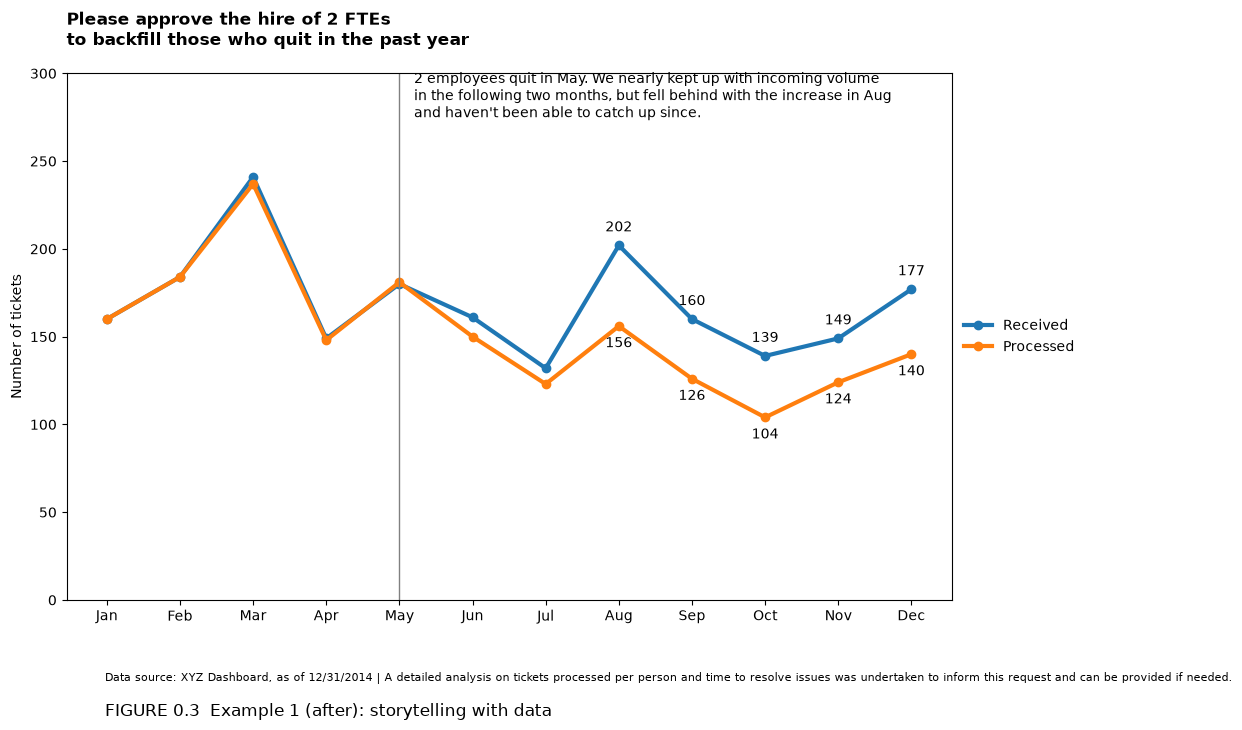

In [ ]:
'''Part 4 reproduce a graph from textbook'''
data4 = {
    "month": [
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
    ],
    "received": [160, 184, 241, 149, 180, 161, 132, 202, 160, 139, 149, 177],
    "processed": [160, 184, 237, 148, 181, 150, 123, 156, 126, 104, 124, 140]
}

df4 = pd.DataFrame(data4)
df4


plt.figure(figsize=(11, 7))

################ Plot lines
plt.plot(
    df4["month"],
    df4["received"],
    marker="o",
    linewidth=3,
    label="Received"
)

plt.plot(
    df4["month"],
    df4["processed"],
    marker="o",
    linewidth=3,
    label="Processed"
)

############# Vertical separator at May
plt.axvline(
    x="May",
    color="gray",
    linewidth=1
)

################# Title
plt.title(
    "Please approve the hire of 2 FTEs\n"
    "to backfill those who quit in the past year\n",
    loc="left",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel("Number of tickets")

############## Annotation block
plt.text(
    4.2,
    275,
    "2 employees quit in May. We nearly kept up with incoming volume\n"
    "in the following two months, but fell behind with the increase in Aug\n"
    "and haven't been able to catch up since.",
    fontsize=10
)

##################################################

start_idx = 7  # August

for i in range(start_idx, len(df4)):

    # Received labels (above)
    plt.text(
        i,
        df4["received"][i] + 8,
        str(df4["received"][i]),
        ha="center"
    )

    # Processed labels (below)
    plt.text(
        i,
        df4["processed"][i] - 12,
        str(df4["processed"][i]),
        ha="center"
    )

# Legend
plt.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

# Limits
plt.ylim(0, 300)

# Remove grid
plt.grid(False)

######################################################################

plt.figtext(
    0.10,
    0.02,
    "Data source: XYZ Dashboard, as of 12/31/2014 | "
    "A detailed analysis on tickets processed per person and "
    "time to resolve issues was undertaken to inform this request "
    "and can be provided if needed.",
    ha="left",
    fontsize=8
)

# Figure caption at bottom

plt.figtext(
    0.10,           # horizontal position
    -0.03,          # vertical position (lower than data source)
    "FIGURE 0.3  Example 1 (after): storytelling with data",
    ha="left",
    fontsize=12
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.show()